# Tier 5 · Notebook 25 — Diffusion Models (DDPM)

> **Goal:** build the generative model behind DALL·E, Stable Diffusion, and Sora — **denoising diffusion** (Ho et al. 2020). The idea is almost suspiciously simple: **gradually add noise to data until it's pure static, then train a network to reverse that — one denoising step at a time.** We derive the forward/reverse processes and the (beautifully simple) training loss, visualize the process on a 2-D toy, and generate MNIST digits.

**Why diffusion took over.** VAEs are stable but blurry (NB23); GANs are sharp but unstable (NB24). Diffusion gets **GAN-level sharpness with regression-loss stability** — you train it with a plain MSE objective (no adversarial game, no posterior). The tradeoff is *slow sampling* (many denoising steps). The core insight: rather than generate an image in one shot (hard), generate it by **iteratively refining noise into signal** over many small, learnable steps (each easy).


## 0. The forward process — data to noise

Define a fixed **forward process** that gradually corrupts a data point $x_0$ over $T$ steps by adding a little Gaussian noise each step:
$$q(x_t \mid x_{t-1}) = \mathcal{N}\big(\sqrt{1-\beta_t}\,x_{t-1},\; \beta_t I\big),$$
where $\beta_t$ is a small **noise schedule** (increasing from ~1e-4 to ~0.02). After enough steps, $x_T$ is indistinguishable from pure noise $\mathcal{N}(0,I)$.

The crucial trick: we don't need to apply $T$ steps to get $x_t$ — there's a **closed form** to jump straight from $x_0$ to any $x_t$. With $\alpha_t = 1-\beta_t$ and $\bar\alpha_t = \prod_{s\le t}\alpha_s$:
$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon, \qquad \varepsilon\sim\mathcal{N}(0,I).$$
So $x_t$ is just the clean image scaled down, plus scaled noise — a single formula. This is what makes training efficient.


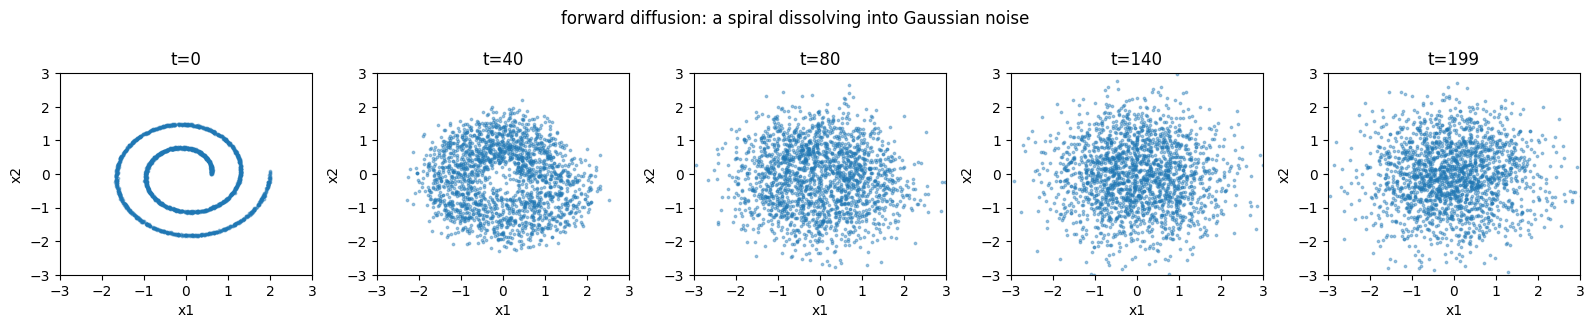

In [1]:
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

T = 200
betas = torch.linspace(1e-4, 0.02, T)
alphas = 1 - betas
abar = torch.cumprod(alphas, 0)                          # alpha_bar_t

def q_sample(x0, t, noise):
    """Jump from x0 to x_t in one step using the closed form."""
    a = abar[t].sqrt().view(-1, *([1]*(x0.dim()-1)))
    a1 = (1-abar[t]).sqrt().view(-1, *([1]*(x0.dim()-1)))
    return a*x0 + a1*noise

# visualize forward diffusion on a 2-D spiral dataset
def spiral(n):
    r = np.linspace(0.3, 1, n); th = np.linspace(0, 4*np.pi, n) + np.random.randn(n)*0.05
    return torch.tensor(np.stack([r*np.cos(th), r*np.sin(th)],1)*2, dtype=torch.float32)
data = spiral(2000)
fig, ax = plt.subplots(1, 5, figsize=(16, 3.3))
for a, tt in zip(ax, [0, 40, 80, 140, 199]):
    xt = q_sample(data, torch.full((len(data),), tt), torch.randn_like(data))
    a.scatter(xt[:,0], xt[:,1], s=3, alpha=0.4); a.set_title(f"t={tt}"); a.set_xlabel("x1"); a.set_ylabel("x2")
    a.set_xlim(-3,3); a.set_ylim(-3,3)
fig.suptitle("forward diffusion: a spiral dissolving into Gaussian noise"); plt.tight_layout(); plt.show()


**What to notice.** The structured spiral **melts into pure Gaussian noise** as $t$ increases — by $t=199$ there's no trace of the spiral left. This forward process is *fixed* (no learning), and thanks to the closed form we can produce any noise level $x_t$ from $x_0$ instantly. The generative model's job is to learn the **reverse**: given a noisy $x_t$, step back toward clean data.


## 1. The reverse process & the (simple) training objective

To generate, we reverse the chain: start from noise $x_T\sim\mathcal{N}(0,I)$ and denoise step by step down to $x_0$. Each reverse step $p_\theta(x_{t-1}\mid x_t)$ is also Gaussian, and Ho et al.'s key result is that the network doesn't need to predict a complicated distribution — it just needs to **predict the noise $\varepsilon$ that was added**. The training loss collapses to a plain mean-squared error:
$$\mathcal{L} = \mathbb{E}_{x_0,\,t,\,\varepsilon}\Big[\,\big\|\,\varepsilon - \varepsilon_\theta(x_t, t)\,\big\|^2\,\Big].$$
In words: take a clean sample, pick a random timestep $t$, noise it to $x_t$ (closed form), and train the network $\varepsilon_\theta$ to **recover the noise** from the noisy input (given $t$). That's it — no adversary, no ELBO, just "guess the noise." At sampling time we use the predicted noise to take one denoising step:
$$x_{t-1} = \tfrac{1}{\sqrt{\alpha_t}}\Big(x_t - \tfrac{1-\alpha_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta(x_t,t)\Big) + \sigma_t z.$$


In [2]:
# a small time-conditioned denoiser for the 2D toy
def time_emb(t, dim=32):
    half = dim//2; freqs = torch.exp(-np.log(10000)*torch.arange(half,device=t.device)/half)
    a = t[:,None].float()*freqs[None]; return torch.cat([a.sin(), a.cos()], -1)

class Denoiser2D(nn.Module):
    def __init__(s, dim=128):
        super().__init__(); s.tmlp=nn.Sequential(nn.Linear(32,dim), nn.ReLU())
        s.net=nn.Sequential(nn.Linear(2+dim,dim), nn.ReLU(), nn.Linear(dim,dim), nn.ReLU(), nn.Linear(dim,2))
    def forward(s,x,t):
        return s.net(torch.cat([x, s.tmlp(time_emb(t))],-1))

model = Denoiser2D().to(device); opt = torch.optim.Adam(model.parameters(), 2e-3)
abar_d, alphas_d, betas_d = abar.to(device), alphas.to(device), betas.to(device)
data_d = data.to(device)
for step in range(4000):
    x0 = data_d[torch.randint(0,len(data_d),(512,),device=device)]
    t = torch.randint(0,T,(512,),device=device); noise = torch.randn_like(x0)
    xt = q_sample(x0.cpu(), t.cpu(), noise.cpu()).to(device)
    loss = F.mse_loss(model(xt,t), noise)           # predict the noise
    opt.zero_grad(); loss.backward(); opt.step()
print(f"2D denoiser trained, final noise-prediction MSE {loss.item():.3f}")

@torch.no_grad()
def sample2d(n, keep=None):
    x = torch.randn(n,2,device=device); traj={}
    for t in reversed(range(T)):
        z = torch.randn_like(x) if t>0 else 0
        eps = model(x, torch.full((n,),t,device=device))
        x = (x - (1-alphas_d[t])/(1-abar_d[t]).sqrt()*eps)/alphas_d[t].sqrt() + betas_d[t].sqrt()*z
        if keep and t in keep: traj[t]=x.cpu().numpy().copy()
    return x.cpu().numpy(), traj


2D denoiser trained, final noise-prediction MSE 0.540


## 2. Reverse sampling — noise back to a spiral

Start from pure noise and run the learned denoiser backward. We snapshot the trajectory to *watch the noise organize itself into the data distribution*.


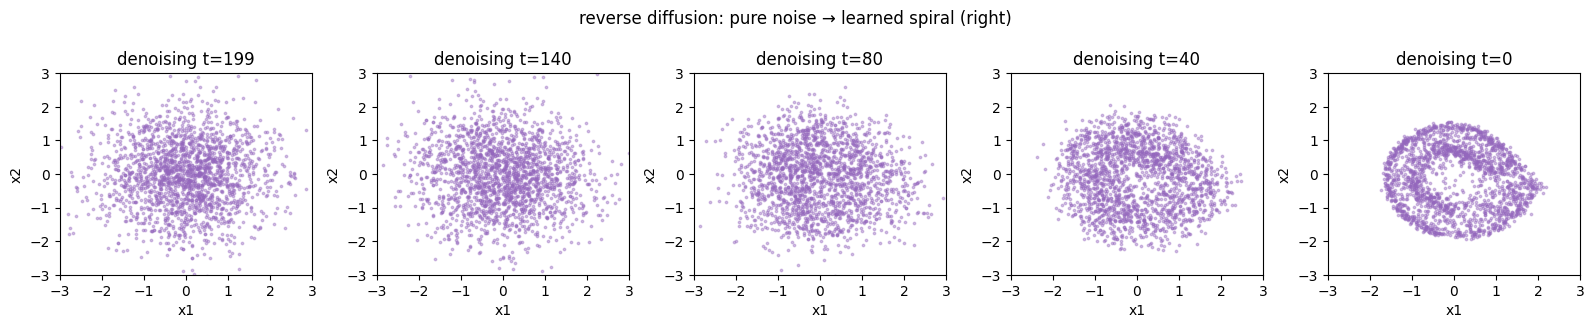

In [3]:
final, traj = sample2d(2000, keep=[199,140,80,40,0])
fig, ax = plt.subplots(1, 5, figsize=(16, 3.3))
for a, tt in zip(ax, [199,140,80,40,0]):
    pts = traj[tt]; a.scatter(pts[:,0], pts[:,1], s=3, alpha=0.4, color="tab:purple")
    a.set_title(f"denoising t={tt}"); a.set_xlabel("x1"); a.set_ylabel("x2"); a.set_xlim(-3,3); a.set_ylim(-3,3)
fig.suptitle("reverse diffusion: pure noise → learned spiral (right)"); plt.tight_layout(); plt.show()


**What to notice.** Running the denoiser backward, the initial **pure noise (t=199) gradually organizes into the spiral (t=0)** — the model learned to reverse the corruption, reconstructing the data manifold from scratch. Each step makes a small, easy correction; the *composition* of 200 easy steps solves the hard generation problem. This is the entire diffusion idea, made visible. Notice there's no mode collapse (unlike the GAN) — diffusion naturally covers the whole distribution because the MSE objective rewards matching *all* the data, not just fooling a discriminator.


## 3. Diffusion on MNIST

Same recipe on images: a small time-conditioned **convolutional** denoiser predicts the noise in a corrupted digit. Generation starts from noise and denoises to a digit. (Small model + MLP-ish conv → not Stable-Diffusion quality, but the mechanism is identical — real image models just use a big U-Net and more steps.)


epoch 0  noise-MSE 0.151


epoch 1  noise-MSE 0.121


epoch 2  noise-MSE 0.110


epoch 3  noise-MSE 0.105


epoch 4  noise-MSE 0.094


epoch 5  noise-MSE 0.086


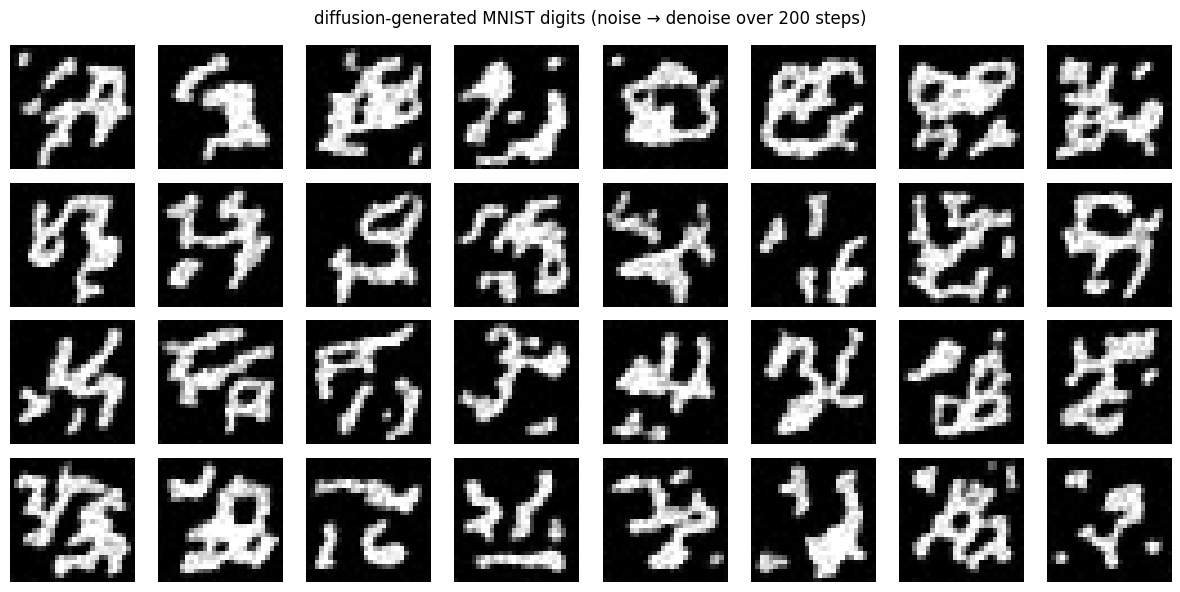

In [4]:
from torchvision import datasets, transforms
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,),(0.5,))])
ld = torch.utils.data.DataLoader(datasets.MNIST("./data",train=True,download=True,transform=tf),
                                 batch_size=128, shuffle=True)

class DenoiserImg(nn.Module):        # tiny time-conditioned conv U-Net-lite
    def __init__(s, c=64):
        super().__init__(); s.tmlp=nn.Sequential(nn.Linear(32,c), nn.ReLU(), nn.Linear(c,c))
        s.e1=nn.Conv2d(1,c,3,padding=1); s.e2=nn.Conv2d(c,c,3,padding=1,stride=2)   # 28->14
        s.mid=nn.Conv2d(c,c,3,padding=1)
        s.d2=nn.ConvTranspose2d(c,c,4,stride=2,padding=1)                           # 14->28
        s.d1=nn.Conv2d(c,1,3,padding=1); s.act=nn.SiLU()
    def forward(s,x,t):
        temb=s.tmlp(time_emb(t))[:,:,None,None]
        h1=s.act(s.e1(x)+temb); h2=s.act(s.e2(h1)+temb); m=s.act(s.mid(h2)+temb)
        u=s.act(s.d2(m)+temb); return s.d1(u+h1)

imodel=DenoiserImg().to(device); opt=torch.optim.Adam(imodel.parameters(),2e-4)
for epoch in range(6):
    for x,_ in ld:
        x=x.to(device); t=torch.randint(0,T,(x.size(0),),device=device); noise=torch.randn_like(x)
        xt=q_sample(x.cpu(),t.cpu(),noise.cpu()).to(device)
        loss=F.mse_loss(imodel(xt,t),noise); opt.zero_grad(); loss.backward(); opt.step()
    print(f"epoch {epoch}  noise-MSE {loss.item():.3f}")

@torch.no_grad()
def sample_img(n):
    x=torch.randn(n,1,28,28,device=device)
    for t in reversed(range(T)):
        z=torch.randn_like(x) if t>0 else 0
        eps=imodel(x,torch.full((n,),t,device=device))
        x=(x-(1-alphas_d[t])/(1-abar_d[t]).sqrt()*eps)/alphas_d[t].sqrt()+betas_d[t].sqrt()*z
    return x.cpu()
gen=sample_img(32)
fig,ax=plt.subplots(4,8,figsize=(12,6))
for i,a in enumerate(ax.ravel()): a.imshow(gen[i,0].clamp(-1,1)*0.5+0.5,cmap="gray"); a.axis("off")
fig.suptitle("diffusion-generated MNIST digits (noise → denoise over 200 steps)"); plt.tight_layout(); plt.show()


**What to notice.** Starting from pure noise, 200 denoising steps produce recognizable MNIST digits — from a **stable MSE training objective** with no adversary and no mode collapse. The quality here is limited by our tiny denoiser and step budget; scale the U-Net and steps (and add conditioning) and this exact recipe becomes Stable Diffusion. The defining diffusion tradeoff is visible: **excellent, diverse, stably-trained samples, but many forward passes per image** (slow sampling) — which is why inference-acceleration methods (DDIM, distillation, consistency models) are a hot area.

## 4. What you built / learned
- The **forward process**: fixed Gaussian corruption with a closed form $x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\varepsilon$.
- The **reverse process** and DDPM's simple **noise-prediction MSE** objective (no adversary, no ELBO).
- **Sampling** by iterative denoising, visualized on a 2-D spiral (noise → data) and on MNIST.
- Why diffusion beats GAN/VAE on the quality–stability frontier, at the cost of slow sampling.

## 5. Exercises
1. **Noise schedules.** Compare linear vs cosine β schedules; the cosine schedule (Nichol & Dhariwal) improves samples — why?
2. **DDIM.** Implement deterministic DDIM sampling; get similar quality in 20 steps instead of 200 (10× faster).
3. **Predict x0 vs ε.** Reparameterize the model to predict $x_0$ directly; relate to ε-prediction.
4. **Classifier-free guidance.** Add class conditioning + guidance; generate a *chosen* digit with a knob for fidelity vs diversity.
5. **Fewer steps.** Reduce T at sampling; where does quality break, and how do consistency models fix it?
6. **Score view.** Show that ε-prediction is equivalent to estimating the score $\nabla_x \log p(x_t)$ (Song & Ermon).

## 6. Interview / residency framing
- *"How does diffusion work?"* → a fixed forward process adds Gaussian noise over T steps; a network learns to reverse it by predicting the noise; sample by denoising from pure noise.
- *"What's the training objective?"* → MSE between true and predicted noise: $\|\varepsilon-\varepsilon_\theta(x_t,t)\|^2$. Simple and stable.
- *"Why the closed form for $x_t$?"* → lets you jump from $x_0$ to any noise level in one step, so training samples random timesteps efficiently.
- *"Diffusion vs GAN?"* → diffusion: stable MSE training, mode coverage, sharp — but slow (many steps); GAN: fast one-shot, sharp — but unstable and mode-collapse-prone.
- *"How to speed up sampling?"* → DDIM (deterministic, fewer steps), distillation, consistency models.

## 📚 References & papers

This notebook reproduces / builds on:

- **Denoising Diffusion Probabilistic Models (DDPM)** — Ho, Jain & Abbeel (2020), arXiv:2006.11239. The paper this notebook implements.
- **Deep Unsupervised Learning using Nonequilibrium Thermodynamics** — Sohl-Dickstein et al. (2015), arXiv:1503.03585. The original diffusion idea.
- **Denoising Diffusion Implicit Models (DDIM)** — Song, Meng & Ermon (2020), arXiv:2010.02502. Fast deterministic sampling.
- **Improved Denoising Diffusion Probabilistic Models** — Nichol & Dhariwal (2021), arXiv:2102.09672. Cosine schedule.
- **Score-Based Generative Modeling through SDEs** — Song et al. (2020), arXiv:2011.13456. The score/SDE view.

---
**Next:** *Tier 5 · Notebook 26 — Normalizing flows*: exact-likelihood generative models via invertible transforms and the change-of-variables formula — the third major generative paradigm.
